In [1]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1,
    return_X_y=True)

X = X.values
y = y.astype(int).values

In [2]:
print("X shape: ", X.shape)
print("y shape: ", y.shape)

X shape:  (70000, 784)
y shape:  (70000,)


In [3]:
# Normalize the data to be between -1 and 1
X = ((X/255)-0.5)*2

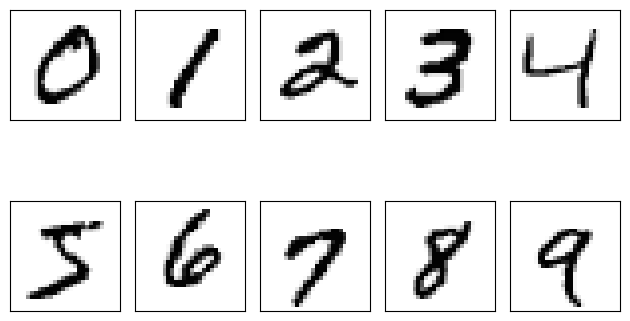

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=2, ncols=5,
    sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

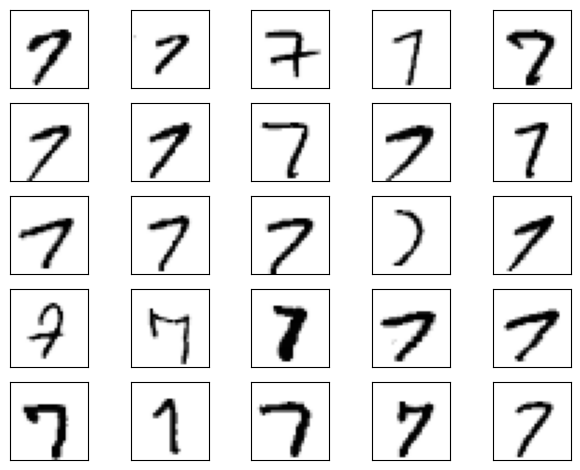

In [5]:
# visualize different handwritten of same digit

fig, ax = plt.subplots(nrows=5,
ncols=5,
sharex=True,
sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()

In [6]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, 
    random_state=123, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=5000,
    random_state=123, stratify=y_temp
)

In [7]:
from mlp import NeuralNetMLP

model = NeuralNetMLP(num_features=28*28,
    num_hidden=50,
    num_classes=10)
